In [2]:
import sys
import os

import importlib
import post_mcmc
import numpy as np
importlib.reload(post_mcmc)
from gala.coordinates import GreatCircleICRSFrame
import astropy.coordinates as coord
from astropy import units as u
import matplotlib.pyplot as plt
from post_mcmc import plot_form

In [3]:
min_dist = 18e3
fr = GreatCircleICRSFrame.from_pole_ra0(pole=coord.SkyCoord(ra=81.45*u.deg, dec=-6.346*u.deg), ra0=354.356*u.deg)

# def get_mem_path from directory, grabbing .fits file that includese 0.5%_mem in the name
def get_mem_path(directory):
    import os
    files = os.listdir(directory)
    for file in files:
        if ('0.5%_mem' in file or '50%_mem' in file) and file.endswith('.fits'):
            return os.path.join(directory, file)

In [4]:
importlib.reload(post_mcmc)
mem_path = get_mem_path('/home/jupyter-nasserm/raid/nasserm/streamTutorialDr1/runs/Sylgr-I21_250915_spline_save')
stream_data, stream_run_directory = post_mcmc.load_stream_mems(mem_path)
stst1 = post_mcmc.StreamMembers(min_dist=18e3, stream_data=stream_data, stream_run_directory=stream_run_directory, fr=fr)

Using default isochrone path: ...iso_a13.5_z0.00010.dat
Loading desi_data...
No desi_data provided, will not use DESI data
Skipping BHB and RRL Data
Done


In [5]:
importlib.reload(post_mcmc)
mem_path = get_mem_path('/home/jupyter-nasserm/raid/nasserm/data/runs/Sylgr-I21_250915_jo_1d_wide2')
stream_data, stream_run_directory = post_mcmc.load_stream_mems(mem_path)
stst2 = post_mcmc.StreamMembers(min_dist=18e3, stream_data=stream_data, stream_run_directory=stream_run_directory, fr=fr)

Using default isochrone path: ...iso_a13.5_z0.00010.dat
Loading desi_data...
No desi_data provided, will not use DESI data
Skipping BHB and RRL Data
Done


113


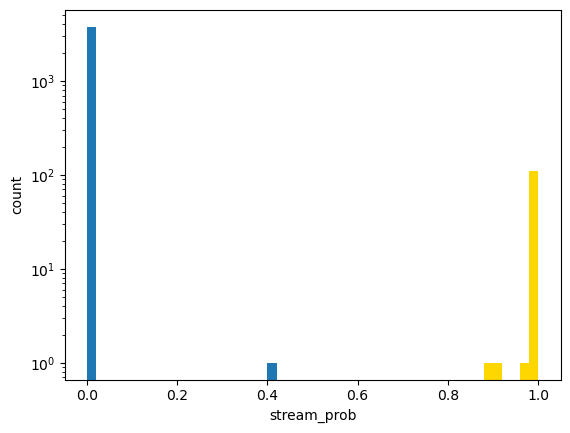

In [6]:
data = stst1.all_memberships['stream_prob']
counts, bins = np.histogram(data, bins=50)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
colors = ['gold' if c >= 0.5 else 'C0' for c in bin_centers]

plt.figure()
plt.bar(bin_centers, counts, width=np.diff(bins), align='center', color=colors)
plt.yscale('log')
plt.xlabel('stream_prob')
plt.ylabel('count')
print(len(data[data >= 0.5]))

116


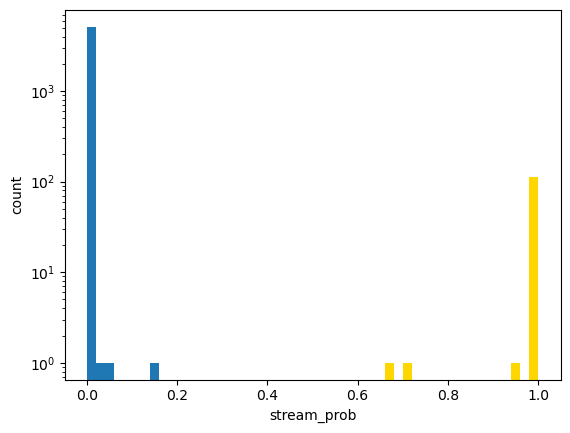

In [7]:
data = stst2.all_memberships['stream_prob']
counts, bins = np.histogram(data, bins=50)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
colors = ['gold' if c >= 0.5 else 'C0' for c in bin_centers]

plt.figure()
plt.bar(bin_centers, counts, width=np.diff(bins), align='center', color=colors)
plt.yscale('log')
plt.xlabel('stream_prob')
plt.ylabel('count')
print(len(data[data >= 0.5]))

In [8]:
importlib.reload(post_mcmc)
compare  = post_mcmc.streamCompare(stst1, stst2)

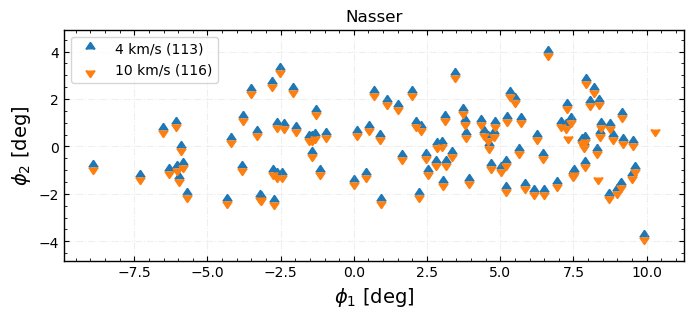

In [9]:
compare.on_sky(stream1_name='4 km/s', stream2_name='10 km/s', title='Nasser')

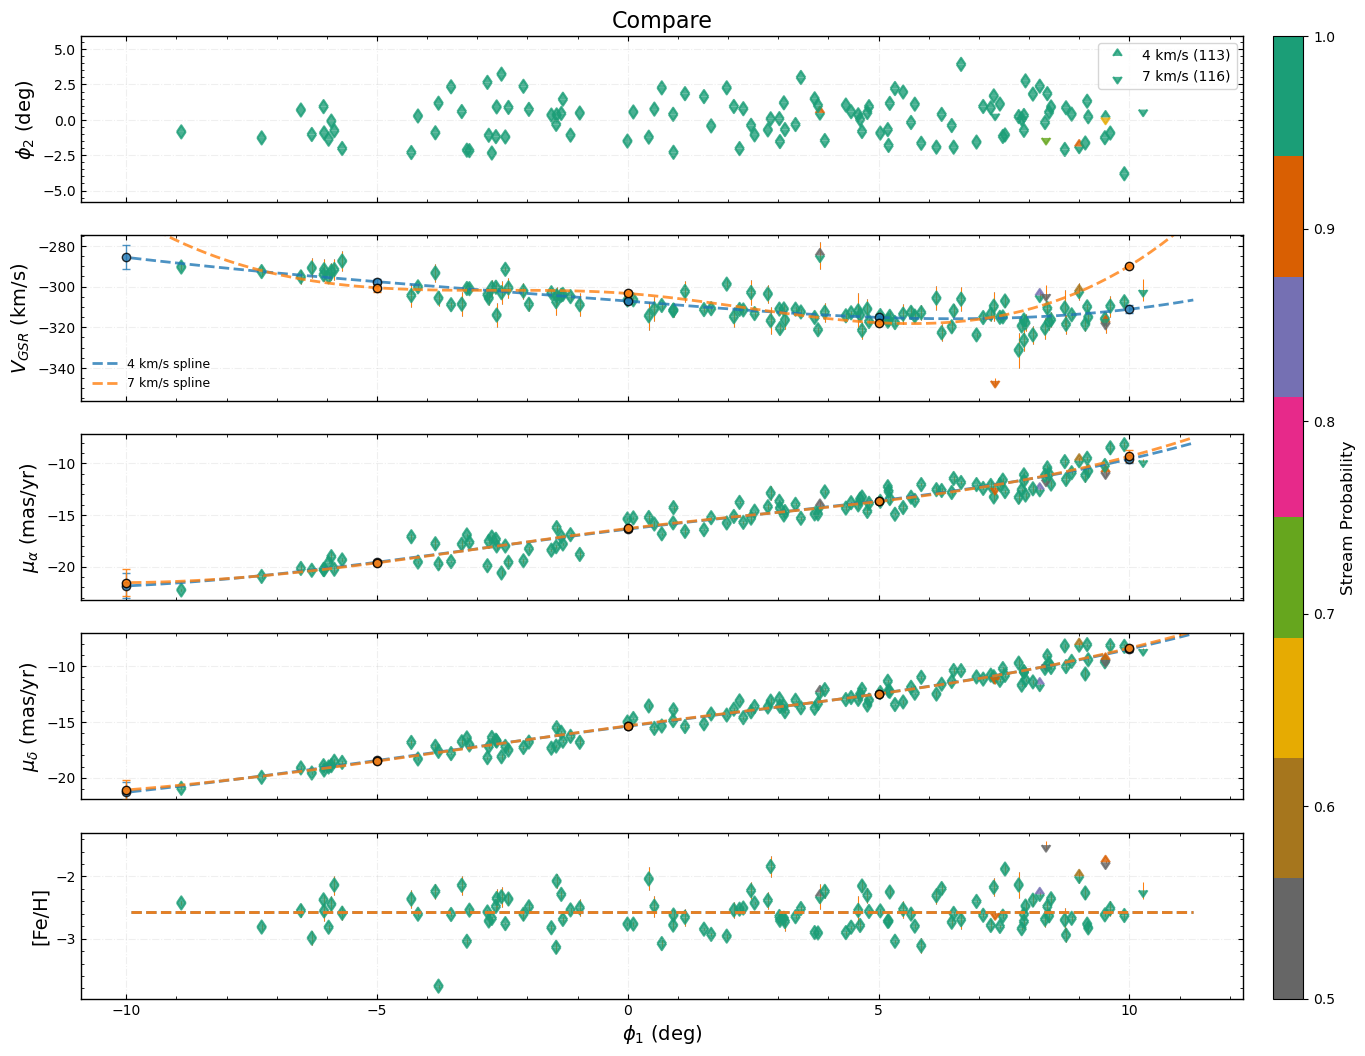

In [11]:
# Test the six6 method with spline tracks
import importlib
importlib.reload(post_mcmc)
# Recreate the compare object to pick up the updated method
compare = post_mcmc.streamCompare(stst1, stst2)
compare.six6(stream1_name='4 km/s', stream2_name='7 km/s', title='Compare', residual=0, cmap='Dark2_r')

In [53]:
sixty4 = stst2.all_memberships[stst2.all_memberships['stream_prob'] >= 0.5]

all = stst1.all_memberships

In [54]:
sixty4

,FEH_ERR,PRIMARY,TARGET_RA,TARGETID,VRAD_ERR,TARGET_DEC,FEH,VRAD,PARALLAX,PMRA_PMDEC_CORR,...,PMRA_ERROR,dist_mod_err,dist_mod,FLUX_G,FLUX_R,EBV,phi1,phi2,VGSR,stream_prob
23,0.072510,True,188.371189,2305843036829000271,3.056707,3.063130,-3.088632,-194.257655,0.055037,-0.300663,...,0.073065,0.719075,14.444197,186.605530,282.115479,0.023115,14.208661,0.734929,-279.374156,0.974552
89,0.144354,True,180.171946,2305843038217307334,5.850161,2.590107,-2.694757,-200.950507,0.218544,-0.282290,...,0.142877,0.208454,12.954934,70.362137,88.940224,0.024642,6.643894,3.924128,-306.193794,0.999854
120,0.109710,True,170.676321,2305843037403611913,4.832696,-7.518038,-2.989820,-136.155209,0.521806,0.008417,...,0.160056,0.153491,12.326080,58.733265,84.776848,0.043728,-6.299746,-1.037058,-290.835218,1.000000
191,0.053864,True,175.549771,2305843037470721074,1.937276,-1.522184,-3.078962,-181.509574,0.210622,0.116697,...,0.064911,0.112728,12.367257,332.296173,412.219116,0.014153,0.677034,2.260631,-309.290459,0.999999
214,0.039570,True,176.711894,2305843037483314152,2.123213,-0.952625,-2.958869,-175.079653,0.241186,-0.201489,...,0.062353,0.181036,11.567667,338.233215,447.934662,0.020630,1.971982,2.264295,-298.776631,0.999995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6792,0.080434,True,182.060205,39627787782325477,3.488172,0.092037,-2.787119,-204.341620,0.693100,-0.265167,...,0.405788,0.647575,13.120321,21.618471,32.108231,0.020803,7.236363,0.849549,-313.484470,0.999970
6892,0.058332,True,183.356352,39627763644106992,2.634827,-1.047509,-2.606995,-206.590038,0.057653,-0.018972,...,0.229927,0.094882,13.133661,35.512295,49.424824,0.022459,7.896792,-0.744895,-316.430427,0.999908
6915,0.083159,True,182.629058,39627824029502205,2.766588,1.488046,-2.482600,-207.234719,-0.028106,-0.069603,...,0.266981,0.176372,13.282818,35.265175,47.053833,0.025915,8.363071,1.851360,-310.680345,0.999393
6930,0.033232,True,182.320384,39627781746722088,1.599816,-0.241553,-2.589634,-236.801733,-0.051643,-0.240947,...,0.221923,0.056438,13.251081,33.756058,45.903397,0.019775,7.322724,0.435403,-346.422583,0.987865


In [55]:
cross_on_id= np.isin(stst1.all_memberships['TARGETID'], sixty4)

In [56]:
all[cross_on_id][all[cross_on_id]['stream_prob'] < 0.5]

,FEH,TEFF,VRAD_ERR,LOGG,PRIMARY,FEH_ERR,TARGETID,TARGET_RA,TARGET_DEC,VRAD,...,PMRA_ERROR,PMDEC,FLUX_G,FLUX_R,FLUX_Z,EBV,VGSR,phi1,phi2,stream_prob
26,-3.088632,5134.146667,3.056707,2.123234,True,0.072510,2305843036829000271,188.371189,3.063130,-194.257655,...,0.073065,-3.548906,186.605530,282.115479,330.913513,0.023115,-279.374156,14.208661,0.734929,3.050480e-15
642,-3.413222,5688.337225,9.768942,4.439262,True,0.240611,2781062891569154,188.785778,4.595588,-169.905636,...,0.900002,-0.214370,7.542978,10.999347,13.054673,0.020008,-249.035671,15.254480,1.929260,1.161239e-18
1226,-2.631739,6085.322068,9.762180,4.154075,True,0.087212,2781062874791939,187.820453,4.587329,-163.083863,...,0.527704,-1.926636,10.725204,14.796979,15.916717,0.019701,-244.545530,14.386245,2.345398,1.484071e-17
3289,-2.865939,6543.394294,5.845559,5.186757,True,0.103741,39627769805541894,190.680537,-0.700470,-151.801637,...,0.310187,-3.492477,26.983751,34.274811,35.328125,0.022760,-243.305198,14.629519,-3.660145,1.122283e-26
3376,-2.466837,6328.725211,7.877110,3.900921,True,0.217180,39627806019159337,189.050149,0.676684,-183.815250,...,0.293060,-3.833812,23.717567,29.731880,31.350088,0.022584,-274.951286,13.768817,-1.706820,2.224257e-08
3572,-2.540845,5363.687635,7.486108,4.799694,True,0.165732,2780936106147844,188.820750,-0.631118,-187.241273,...,0.642968,-4.117451,12.788281,20.258024,25.351444,0.023275,-283.057661,12.987003,-2.780453,6.150308e-06
4008,-1.998949,5702.111947,4.059861,4.487534,True,0.100215,39627751589677314,184.853528,-1.596655,-194.294734,...,0.231411,-8.105483,27.265600,40.477531,47.420395,0.023753,-302.450702,8.997847,-1.898259,2.447140e-01
5594,-2.307489,6168.204414,1.648306,4.185765,True,0.034291,39627757717557310,190.214182,-1.185201,-140.664745,...,0.173217,-4.356483,46.509956,62.372261,68.818657,0.036522,-234.829831,13.996334,-3.890809,2.174815e-81
5722,-2.361235,6368.843356,1.534453,4.769516,True,0.029617,39627781847385579,188.340449,-0.200182,-193.394555,...,0.156663,-5.402350,46.132545,60.489910,63.398533,0.020769,-289.010710,12.745169,-2.182116,6.424587e-10
5777,-2.445909,6275.202457,1.995394,4.730785,True,0.041745,39627787895571993,188.849317,-0.097767,-194.335030,...,0.243667,-3.906521,23.721199,31.243670,33.329575,0.022811,-288.405470,13.247573,-2.314067,1.178791e-12


/raid5b/users/nasserm/raid/nasserm/c19_2025/post_mcmc.py:2324: UserWarning: Rasterization of 'Spine' will be ignored



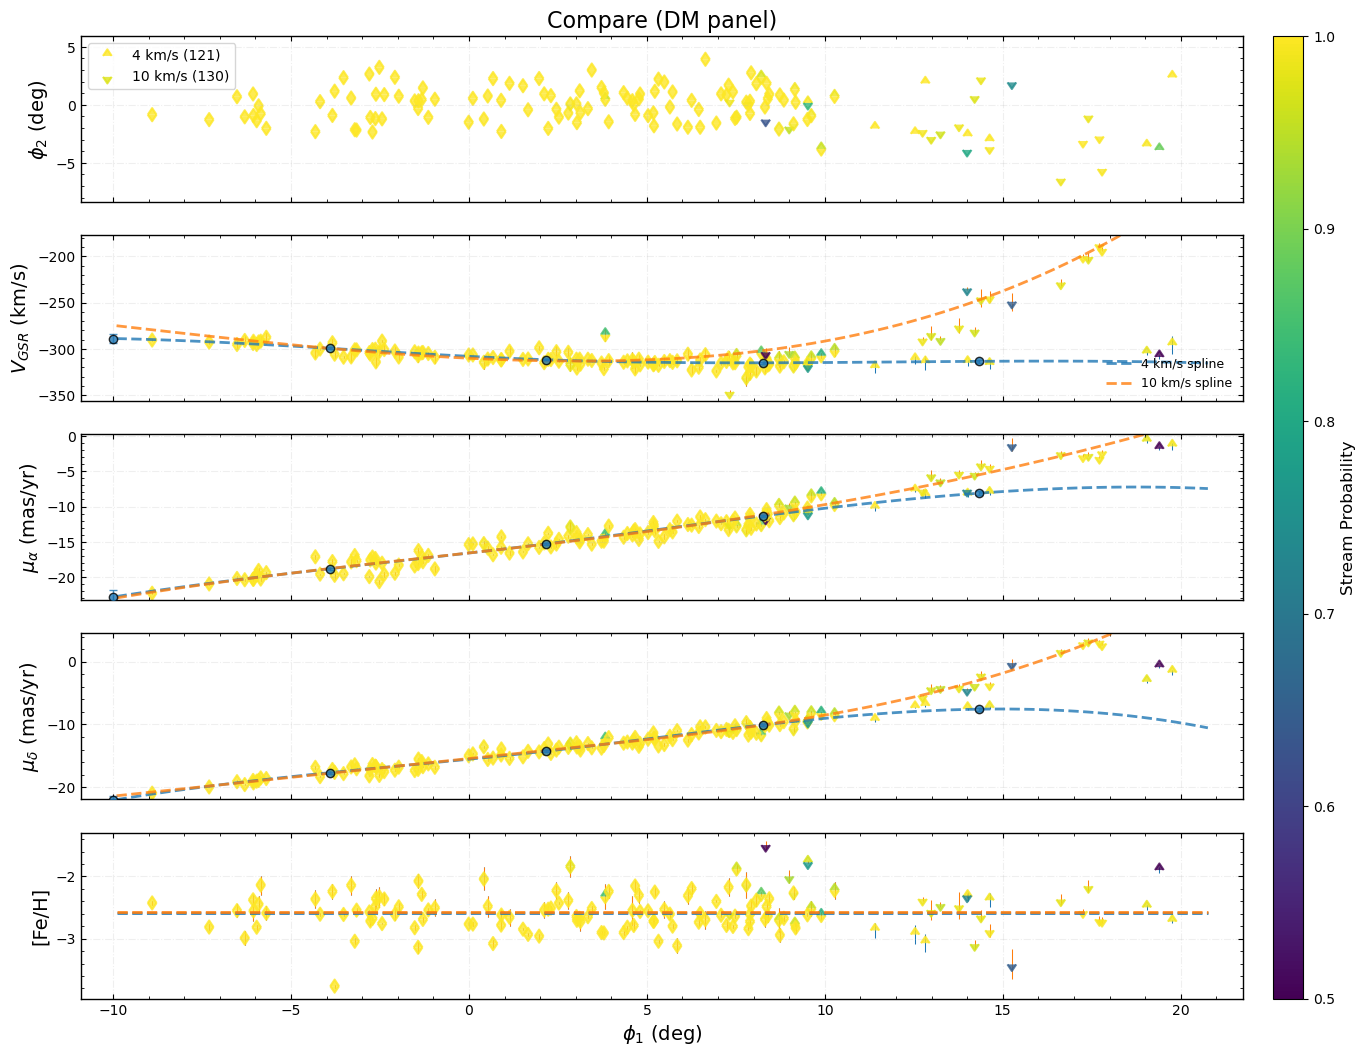

In [58]:

importlib.reload(post_mcmc)
compare.six6(stream1_name='4 km/s', stream2_name='10 km/s', title='Compare (DM panel)', residual=0
             , dist_mod_panel=True)